# Estudo de classificação de inadimplência e de tratamento de desbalanceamento.


Este projeto tem como objetivo praticar e aprender técnicas de Machine Learning, com foco no balanceamento de dados utilizando SMOTENC, na busca de hiperparâmetros com GridSearchCV e no uso de Pipelines para evitar data leakage.

# Dados

Dados do github da Cibele Russo, disponíveis em https://github.com/cibelerusso/Datasets/blob/main/amostra_banco.csv


In [213]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

df = pd.read_csv('https://raw.githubusercontent.com/cibelerusso/Datasets/main/amostra_banco.csv')


In [214]:
df.head()

,Unnamed: 0,Cliente,Sexo,Idade,Empresa,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente
0,33227,33227,M,38,Privada,6467,993.18,0.00,0.00,2038.32,1
1,64805,64805,M,33,Privada,5764,1167.27,0.00,0.00,4617.05,1
2,39764,39764,F,35,Privada,5417,667.30,0.00,0.00,5726.83,1
3,51271,51271,M,36,Privada,5858,846.53,0.00,0.00,1723.74,1
4,9699,9699,M,32,Privada,5579,768.90,16801.57,8138.71,0.00,0


In [215]:
df.describe()

,Unnamed: 0,Cliente,Idade,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,50769.254000,50769.254000,31.980000,5533.932000,838.540340,1855.374460,1238.039780,2545.620400,0.242000
std,28628.982131,28628.982131,3.136123,433.666199,244.251991,5239.894204,3623.469665,1647.445353,0.428723
min,106.000000,106.000000,24.000000,4459.000000,112.050000,0.000000,0.000000,0.000000,0.000000
25%,24969.750000,24969.750000,30.000000,5250.000000,681.260000,0.000000,0.000000,1477.612500,0.000000
50%,51873.500000,51873.500000,32.000000,5533.000000,834.005000,0.000000,0.000000,2533.795000,0.000000
75%,76409.500000,76409.500000,34.000000,5779.250000,1002.777500,0.000000,0.000000,3731.877500,0.000000
max,99985.000000,99985.000000,53.000000,8915.000000,1838.560000,18452.970000,18363.060000,7273.920000,1.000000


In [216]:
df.shape

(500, 11)

In [217]:
df.isnull().sum()

,0
Unnamed: 0,0
Cliente,0
Sexo,0
Idade,0
Empresa,0
Salario,0
Saldo_cc,0
Saldo_poupança,0
Saldo_investimento,0
Devedor_cartao,0


Não há dados faltantes.


In [218]:
df['Inadimplente'].value_counts()

,count
Inadimplente,
0,379
1,121


<Axes: xlabel='Inadimplente', ylabel='count'>

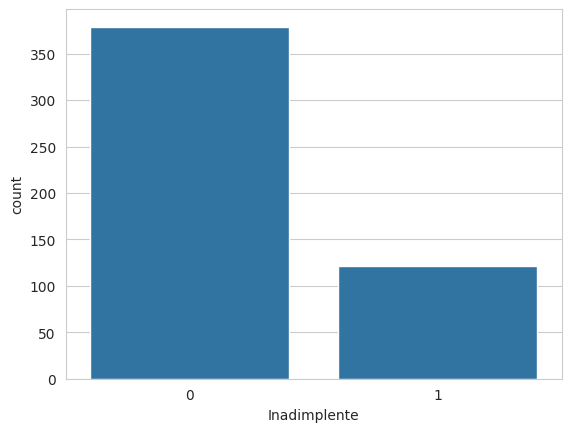

In [219]:
sns.countplot(data=df, x='Inadimplente')

### Histograma Comparativo de Variáveis Quantitativas por Status de Inadimplência

Agora, vamos gerar histogramas para cada variável quantitativa, comparando a distribuição entre clientes inadimplentes e não inadimplentes. Isso nos ajudará a visualizar se há diferenças significativas nas distribuições dessas variáveis para os dois grupos.

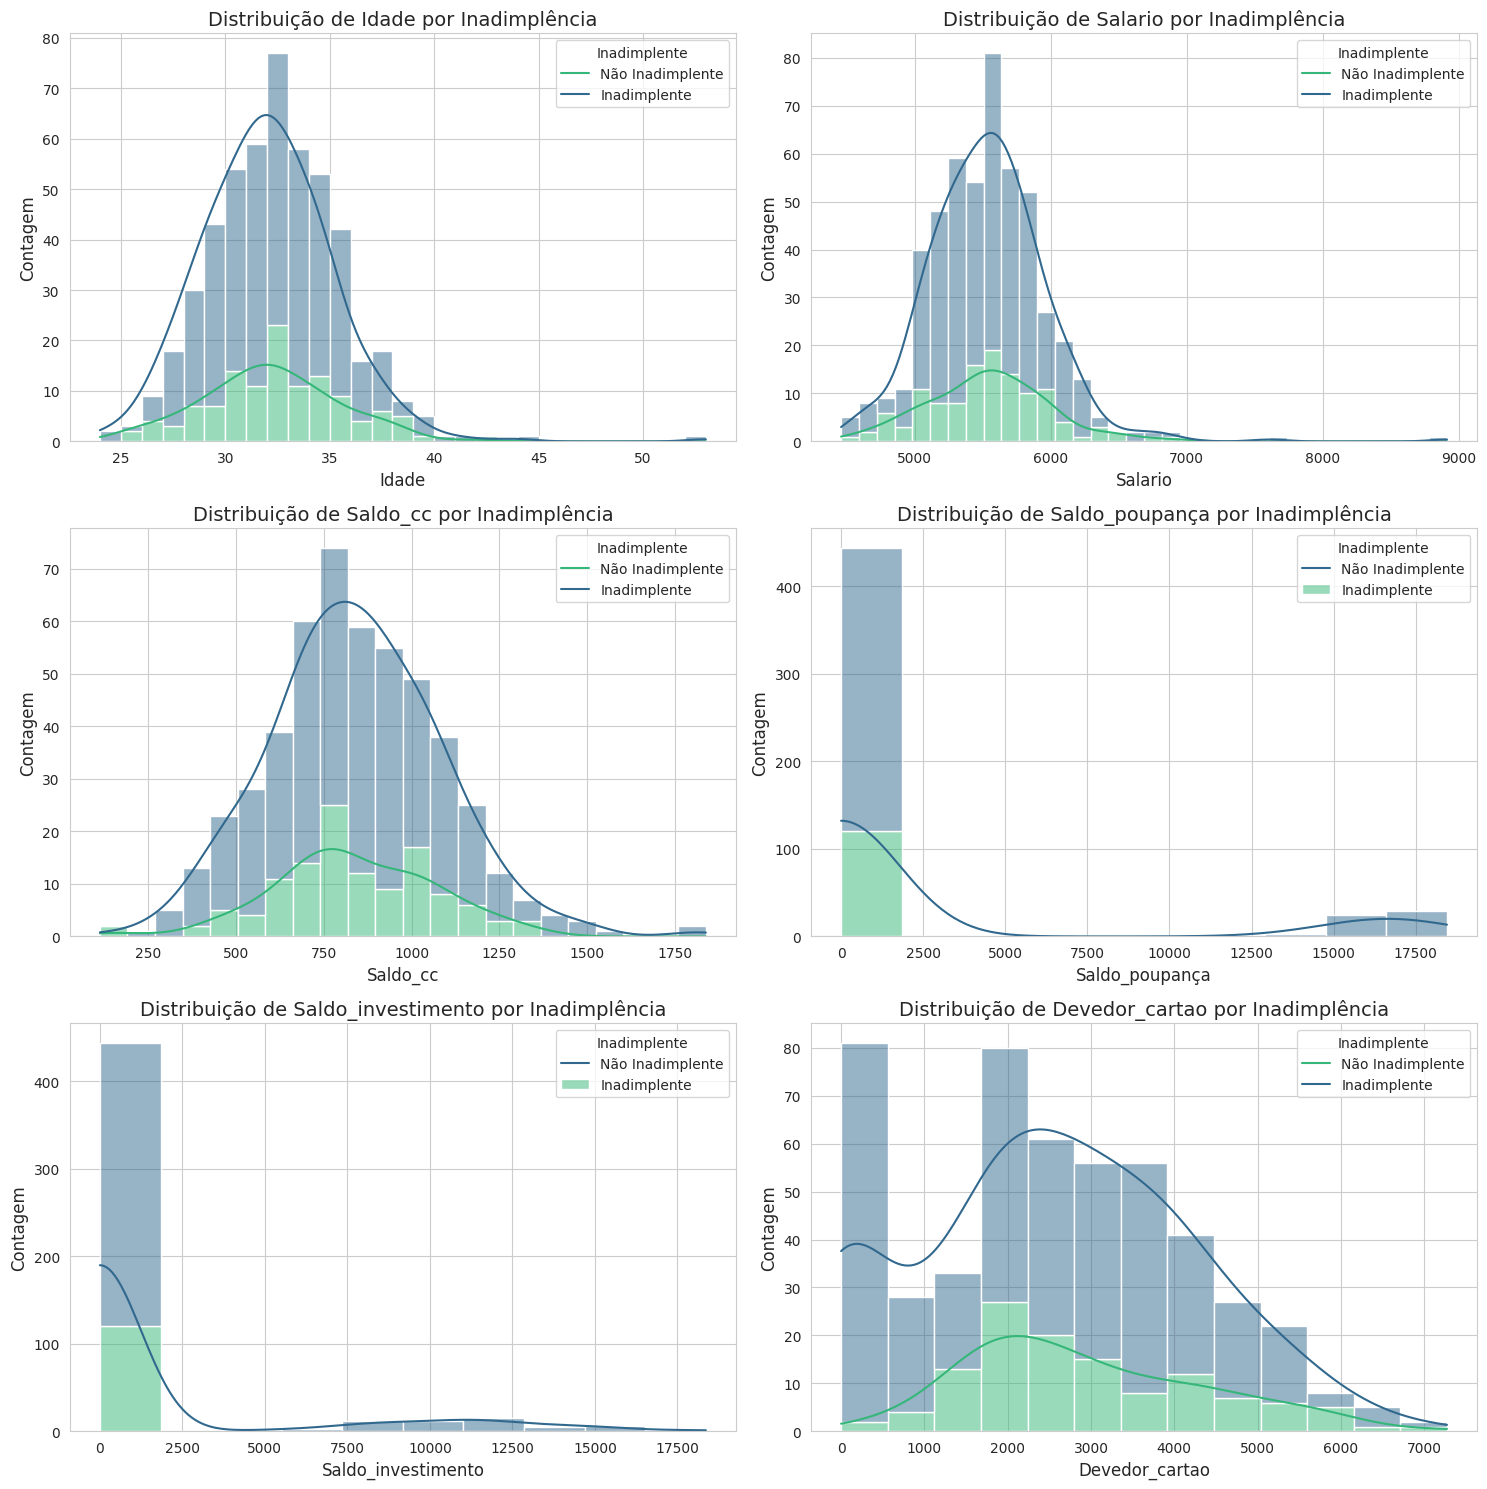

In [220]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')


rows = (len(vars_quant) + 1) // 2
fig, axes = plt.subplots(nrows=rows, ncols=2, figsize=(15, 5 * rows))
axes = axes.flatten()

for i, col in enumerate(vars_quant):
    sns.histplot(data=df, x=col, hue='Inadimplente', multiple='stack', kde=True, palette='viridis', ax=axes[i])
    axes[i].set_title(f'Distribuição de {col} por Inadimplência', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Contagem', fontsize=12)
    axes[i].legend(title='Inadimplente', labels=['Não Inadimplente', 'Inadimplente'], loc='upper right')

# Remover subplots vazios, se houver
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Observa-se que as distribuições de idade e salário apresentam forte sobreposição entre clientes inadimplentes e não inadimplentes. Para o saldo em conta corrente e a dívida de cartão, entretanto, observam-se diferenças nas distribuições dos dois grupos. As variáveis de poupança e investimento apresentam forte assimetria, com grande concentração de valores próximos de zero e a presença de alguns valores elevados.

In [221]:

numerical_cols = df.select_dtypes(include = 'number').columns
categorical_cols = df.select_dtypes(exclude = 'number').columns

categorical_cols

Index(['Sexo', 'Empresa'], dtype='object')

 Transformando dados categóricos em números, para poder treinar o modelo.

In [222]:
df_dummies = pd.get_dummies(df, columns = categorical_cols, drop_first = True)

df_dummies.head()

,Unnamed: 0,Cliente,Idade,Salario,Saldo_cc,Saldo_poupança,Saldo_investimento,Devedor_cartao,Inadimplente,Sexo_M,Empresa_Privada,Empresa_Pública
0,33227,33227,38,6467,993.18,0.00,0.00,2038.32,1,True,True,False
1,64805,64805,33,5764,1167.27,0.00,0.00,4617.05,1,True,True,False
2,39764,39764,35,5417,667.30,0.00,0.00,5726.83,1,False,True,False
3,51271,51271,36,5858,846.53,0.00,0.00,1723.74,1,True,True,False
4,9699,9699,32,5579,768.90,16801.57,8138.71,0.00,0,True,True,False


In [223]:
# Features
X = df_dummies.drop(['Inadimplente', 'Unnamed: 0', 'Cliente'], axis =1)

# Target
y = df_dummies['Inadimplente']

In [224]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, random_state=42)
forest = RandomForestClassifier(n_estimators=100, random_state=0, max_depth = 12)
forest.fit(X_train, y_train)


y_pred = forest.predict(X_test)


In [225]:
print("Acurácia nos dados de treinamento: {:.3f}".format(forest.score(X_train, y_train)))
print("Acurácia nos dados de teste: {:.3f}".format(forest.score(X_test, y_test)))


Acurácia nos dados de treinamento: 0.992
Acurácia nos dados de teste: 0.736


In [226]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Precision: 0.2857
Recall: 0.1481
F1-score: 0.1951


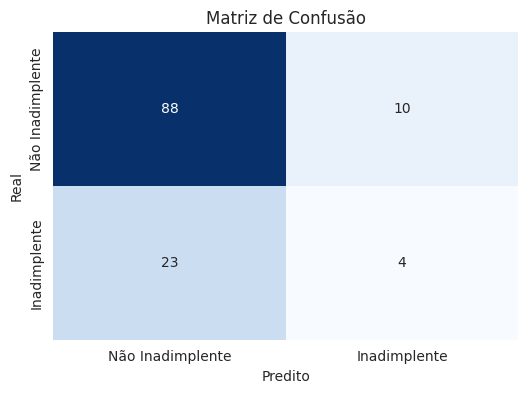

In [227]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Inadimplente', 'Inadimplente'],
            yticklabels=['Não Inadimplente', 'Inadimplente'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# Análise das métricas


*    A precisão é bastante baixa. Isso indica que, das vezes que o modelo previu um cliente como 'Inadimplente', apenas 28.57% dessas previsões estavam corretas. Há muitos falsos positivos, ou seja, o modelo está marcando muitos clientes como inadimplentes que na verdade não são.

*  O recall é muito baixo. Isso significa que o modelo conseguiu identificar apenas 14.81% de todos os clientes que realmente eram inadimplentes. Há um alto número de falsos negativos, ou seja, o modelo está falhando em identificar a maioria dos inadimplentes reais.



A matriz de confusão plotada acima ajuda a visualizar o desempenho do modelo até agora.



In [228]:
print(f"Número de clientes inadimplentes: {len(df[df['Inadimplente'] == 1])}")
print(f"Número de clientes não inadimplentes: {len(df[df['Inadimplente'] == 0])}")



Número de clientes inadimplentes: 121
Número de clientes não inadimplentes: 379


Os clientes inadimplentes formam uma classe minoritária, vamos aplicar uma técnica de over-sampling para melhorar nosso modelo. Como a classe inadimplente é sub-representada os modelos de ML costumam ignorar a classe.

### 1. Tratamento de Desbalanceamento com SMOTENC

Vamos aplicar o SMOTENC para gerar amostras sintéticas da classe minoritária, mantendo o tratamento adequado das variáveis categóricas.


In [229]:
from imblearn.over_sampling import SMOTENC

# Para o SMOTENC, mantemos as variáveis categóricas em seu formato original.
X_mixed = df.drop(['Inadimplente', 'Unnamed: 0', 'Cliente'], axis=1)
categorical_features = X_mixed.select_dtypes(exclude='number').columns.tolist()

X_train_mixed, X_test_mixed, y_train_mixed, y_test_mixed = train_test_split(
    X_mixed, y, random_state=42
)

sm = SMOTENC(
    categorical_features=categorical_features,
    random_state=42
)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train_mixed, y_train_mixed)

print(f"Número de amostras no target de treino antes do SMOTENC: {y_train_mixed.value_counts()}")
print(f"Número de amostras no target de treino depois do SMOTENC: {y_train_resampled.value_counts()}")


Número de amostras no target de treino antes do SMOTENC: Inadimplente
0    281
1     94
Name: count, dtype: int64
Número de amostras no target de treino depois do SMOTENC: Inadimplente
0    281
1    281
Name: count, dtype: int64


### 2. Treinando o Modelo Random Forest com Dados Balanceados

Agora, vamos treinar o `RandomForestClassifier` utilizando os dados de treino balanceados pelo SMOTENC.


In [230]:
from sklearn.ensemble import RandomForestClassifier

# O SMOTENC preserva as variáveis categóricas; fazemos o one-hot encoding depois do oversampling.
X_train_resampled_encoded = pd.get_dummies(
    X_train_resampled, columns=categorical_features, drop_first=True
)
X_test_encoded = pd.get_dummies(
    X_test_mixed, columns=categorical_features, drop_first=True
)

# Garantir as mesmas colunas e a mesma ordem entre treino e teste.
X_train_resampled_encoded, X_test_encoded = X_train_resampled_encoded.align(
    X_test_encoded, join='left', axis=1, fill_value=0
)
X_test_encoded = X_test_encoded[X_train_resampled_encoded.columns]

forest_resampled = RandomForestClassifier(
    n_estimators=100, random_state=0, max_depth=12
)
forest_resampled.fit(X_train_resampled_encoded, y_train_resampled)


RandomForestClassifier(max_depth=12, random_state=0)

### 3. Avaliando o Modelo com Dados Balanceados

Vamos reavaliar o modelo no conjunto de teste original (`X_test`, `y_test`) para verificar se o SMOTE melhorou a detecção de inadimplentes, olhando principalmente para precisão, recall e F1-score da classe positiva.

Acurácia (Resampled): 0.6720
Precision (Resampled): 0.2667
Recall (Resampled): 0.2963
F1-score (Resampled): 0.2807


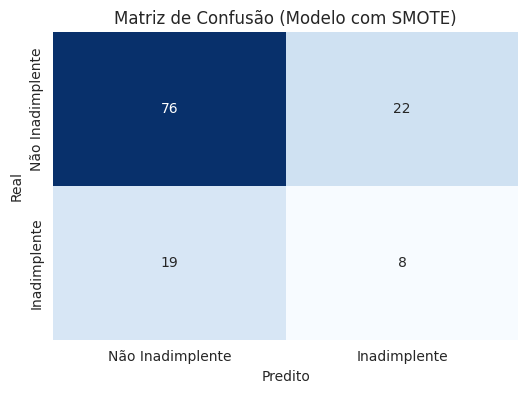

In [231]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_resampled = forest_resampled.predict(X_test_encoded)

accuracy_resampled = accuracy_score(y_test, y_pred_resampled)
precision_resampled = precision_score(y_test, y_pred_resampled)
recall_resampled = recall_score(y_test, y_pred_resampled)
f1_resampled = f1_score(y_test, y_pred_resampled)

print(f'Acurácia (Resampled): {accuracy_resampled:.4f}')
print(f'Precision (Resampled): {precision_resampled:.4f}')
print(f'Recall (Resampled): {recall_resampled:.4f}')
print(f'F1-score (Resampled): {f1_resampled:.4f}')

cm_resampled = confusion_matrix(y_test, y_pred_resampled)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_resampled, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Inadimplente', 'Inadimplente'],
            yticklabels=['Não Inadimplente', 'Inadimplente'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Modelo com SMOTE)')
plt.show()

### 4. Otimização de Hiperparâmetros com GridSearchCV

O `SMOTENC` e o pré-processamento serão colocados dentro de um `Pipeline`, para que o oversampling seja realizado dentro de cada divisão da validação cruzada, evitando vazamento de informação entre treino e validação.


In [232]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTENC
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV

# O pré-processamento e o SMOTENC ficam dentro do pipeline para que, em cada
# fold da validação cruzada, o oversampling seja feito apenas nos dados de treino.
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

pipeline = Pipeline([
    ('smote', SMOTENC(categorical_features=categorical_features, random_state=42)),
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(random_state=0))
])

param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='precision',
    n_jobs=-1,
    verbose=1
)

# O GridSearchCV recebe os dados de treino originais; o SMOTENC é aplicado
# separadamente dentro de cada fold, evitando vazamento para a validação.
grid_search.fit(X_train_mixed, y_train_mixed)

print(f"Melhores parâmetros encontrados: {grid_search.best_params_}")
print(f"Melhor F1-score na validação cruzada: {grid_search.best_score_:.4f}")

melhor_modelo = grid_search.best_estimator_


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Melhores parâmetros encontrados: {'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Melhor F1-score na validação cruzada: 0.3501


### 5. Avaliando o Modelo Otimizado

Vamos avaliar o desempenho do `RandomForestClassifier` com os melhores hiperparâmetros encontrados pelo `GridSearchCV` no conjunto de teste original.

Acurácia (Otimizado): 0.6800
Precision (Otimizado): 0.2759
Recall (Otimizado): 0.2963
F1-score (Otimizado): 0.2857


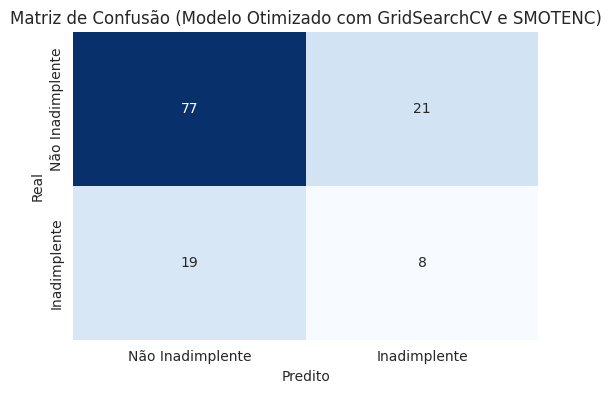

In [233]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_otimizado = melhor_modelo.predict(X_test_mixed)

accuracy_otimizado= accuracy_score(y_test, y_pred_otimizado)
precision_otimizado = precision_score(y_test, y_pred_otimizado)
recall_otimizado = recall_score(y_test, y_pred_otimizado)
f1_otimizado = f1_score(y_test, y_pred_otimizado)

print(f'Acurácia (Otimizado): {accuracy_otimizado:.4f}')
print(f'Precision (Otimizado): {precision_otimizado:.4f}')
print(f'Recall (Otimizado): {recall_otimizado:.4f}')
print(f'F1-score (Otimizado): {f1_otimizado:.4f}')

cm_otimizado = confusion_matrix(y_test, y_pred_otimizado)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_otimizado, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Não Inadimplente', 'Inadimplente'],
            yticklabels=['Não Inadimplente', 'Inadimplente'])
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Modelo Otimizado com GridSearchCV e SMOTENC)')
plt.show()

# Conclusões

Neste projeto, o modelo conseguiu identificar alguns clientes inadimplentes, mas apresentou bastante dificuldade para encontrar essa classe corretamente. Isso ficou claro principalmente no modelo inicial, que teve uma acurácia relativamente alta, mas um recall baixo para os inadimplentes.

Ao aplicar o SMOTENC, o modelo passou a identificar uma parcela maior dos clientes inadimplentes. O recall aumentou de 14,81% para 29,63%, e o F1-score também melhorou. Por outro lado, essa melhora veio acompanhada de uma redução na acurácia e na precisão. Ou seja, o modelo passou a encontrar mais inadimplentes, mas também passou a classificar alguns clientes não inadimplentes como inadimplentes.

Nesse problema, o recall é especialmente importante, porque deixar de identificar um cliente que realmente é inadimplente pode ser mais problemático do que classificar um cliente não inadimplente como inadimplente. Por isso, olhar apenas para a acurácia não seria suficiente para avaliar o modelo.

De forma geral, o balanceamento trouxe uma melhora na identificação da classe minoritária, mas não resolveu completamente o problema. Como próximos passos, seria interessante testar outros modelos, explorar melhor os hiperparâmetros e experimentar diferentes formas de lidar com o desbalanceamento para tentar melhorar o desempenho sem aumentar tanto o número de falsos positivos.